In [9]:
import numpy as np 
np.set_printoptions(precision=4)
rng = np.random.default_rng(1)

import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath(".."))

import matplotlib as mpl
mpl.rcParams['axes.linewidth'] = 3
mpl.rcParams['axes.titlesize'] = 20
mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['axes.titlepad'] = 8.0
mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['xtick.major.width'] = 3
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['ytick.major.size'] = 6
mpl.rcParams['ytick.major.width'] = 3
mpl.rcParams['ytick.labelsize'] = 20
mpl.rcParams['lines.markersize'] = 5
mpl.rcParams['legend.fontsize'] = 15


In [ ]:
import numpy as np
from src.optimizer.al_ilqr_base import AL_iLQR_template


class AL_iLQR_pointmass_ergodic_obstacle(AL_iLQR_template):

    def __init__(
        self,
        dt,
        tsteps,
        x_dim,
        u_dim,
        Q_z,
        R_v,
        R,
        ks,
        L_list,
        lamk_list,
        hk_list,
        phik_list,
        obstacle_center,
        obstacle_radius
    ):

        super().__init__(
            dt,
            tsteps,
            x_dim,
            u_dim,
            Q_z,
            R_v,
        )

        self.R = R

        self.ks = ks
        self.L_list = L_list
        self.lamk_list = lamk_list
        self.hk_list = hk_list
        self.phik_list = phik_list

        self.obs_radius = obstacle_radius
        self.obs_center = obstacle_center

        self.x_min = 0.0
        self.x_max = 1.0

        self.y_min = 0.0
        self.y_max = 1.0

    # ==================================================
    # dynamics
    # ==================================================

    def dyn(self, xt, ut):
        return ut

    def get_At_mat(self, t_idx):
        return np.zeros((self.x_dim, self.x_dim))

    def get_Bt_mat(self, t_idx):
        return np.eye(self.u_dim)

    # ==================================================
    # objective
    # ==================================================

    def objective(self, x_traj, u_traj):

        fk_all = (
            np.prod(
                np.cos(
                    np.pi
                    * self.ks
                    / self.L_list
                    * x_traj[:, None]
                ),
                axis=2
            )
            / self.hk_list
        )

        ck_all = (
            np.sum(fk_all, axis=0)
            / self.tsteps
        )

        erg_metric = np.sum(
            self.lamk_list
            * np.square(ck_all - self.phik_list)
        )

        ctrl_cost = (
            np.sum(self.R @ u_traj.T * u_traj.T)
            * self.dt
        )

        return erg_metric + ctrl_cost

    # ==================================================
    # inequality constraint
    # ==================================================

    def inequality(self, x_traj, u_traj):

        # =====================================
        # obstacle constraint
        #
        # g_obs <= 0
        # =====================================

        obs_diff = x_traj[:, 0:2] - self.obs_center

        g_obs = (
            self.obs_radius**2
            - np.sum(obs_diff**2, axis=1)
        )

        # =====================================
        # workspace boundary constraints
        #
        # xmin <= x <= xmax
        # ymin <= y <= ymax
        #
        # all expressed as g(x)<=0
        # =====================================

        g_xmin = self.x_min - x_traj[:, 0]
        g_xmax = x_traj[:, 0] - self.x_max

        g_ymin = self.y_min - x_traj[:, 1]
        g_ymax = x_traj[:, 1] - self.y_max

        # =====================================
        # concatenate all constraints
        # =====================================

        g_all = np.concatenate([
            g_obs,
            g_xmin,
            g_xmax,
            g_ymin,
            g_ymax,
        ])

        return g_all

    # ==================================================
    # objective gradient
    # ==================================================
    def get_at_vec_constraint(self, t_idx):

        xt = self.curr_x_traj[t_idx]

        grads = []

        # ====================================
        # obstacle
        # ====================================

        grad_obs = np.zeros(self.x_dim)

        grad_obs[0:2] = -2.0 * (
            xt[0:2] - self.obs_center
        )

        grads.append(grad_obs)

        # ====================================
        # xmin
        # g = xmin - x
        # ====================================

        grad_xmin = np.zeros(self.x_dim)
        grad_xmin[0] = -1.0

        grads.append(grad_xmin)

        # ====================================
        # xmax
        # g = x - xmax
        # ====================================

        grad_xmax = np.zeros(self.x_dim)
        grad_xmax[0] = 1.0

        grads.append(grad_xmax)

        # ====================================
        # ymin
        # ====================================

        grad_ymin = np.zeros(self.x_dim)
        grad_ymin[1] = -1.0

        grads.append(grad_ymin)

        # ====================================
        # ymax
        # ====================================

        grad_ymax = np.zeros(self.x_dim)
        grad_ymax[1] = 1.0

        grads.append(grad_ymax)

        return np.array(grads)
    # def get_at_vec_objective(self, t_idx):

    #     xt = self.curr_x_traj[t_idx]

    #     x_traj = self.curr_x_traj

    #     dfk_xt_all = np.array([

    #         -np.pi
    #         * self.ks[:, 0]
    #         / self.L_list[0]
    #         * np.sin(
    #             np.pi
    #             * self.ks[:, 0]
    #             / self.L_list[0]
    #             * xt[0]
    #         )
    #         * np.cos(
    #             np.pi
    #             * self.ks[:, 1]
    #             / self.L_list[1]
    #             * xt[1]
    #         ),

    #         -np.pi
    #         * self.ks[:, 1]
    #         / self.L_list[1]
    #         * np.cos(
    #             np.pi
    #             * self.ks[:, 0]
    #             / self.L_list[0]
    #             * xt[0]
    #         )
    #         * np.sin(
    #             np.pi
    #             * self.ks[:, 1]
    #             / self.L_list[1]
    #             * xt[1]
    #         ),

    #     ]) / self.hk_list

    #     fk_all = (
    #         np.prod(
    #             np.cos(
    #                 np.pi
    #                 * self.ks
    #                 / self.L_list
    #                 * x_traj[:, None]
    #             ),
    #             axis=2
    #         )
    #         / self.hk_list
    #     )

    #     ck_all = (
    #         np.sum(fk_all, axis=0)
    #         / self.tsteps
    #     )

    #     at = np.sum(
    #         self.lamk_list
    #         * 2.0
    #         * (ck_all - self.phik_list)
    #         * dfk_xt_all
    #         / self.tsteps,
    #         axis=1
    #     )

    #     return at

    # def get_bt_vec_objective(self, t_idx):

    #     ut = self.curr_u_traj[t_idx]

    #     return self.R @ ut

    def get_bt_vec_constraint(self, t_idx):

        return np.zeros((5, self.u_dim))

    # ==================================================
    # constraint gradient
    # ==================================================

    def get_at_vec_constraint(self, t_idx):

        xt = self.curr_x_traj[t_idx]

        diff = xt[0:2] - self.obs_center

        grad_g = -2.0 * diff

        return grad_g[None, :]

    def get_bt_vec_constraint(self, t_idx):

        return np.zeros((1, self.u_dim))

In [11]:
from scipy.stats import multivariate_normal as mvn
# Define the target distribution
mean1 = np.array([0.35, 0.38])
cov1 = np.array([
    [0.01, 0.004],
    [0.004, 0.01]
])
w1 = 0.5

mean2 = np.array([0.68, 0.25])
cov2 = np.array([
    [0.005, -0.003],
    [-0.003, 0.005]
])
w2 = 0.2

mean3 = np.array([0.56, 0.64])
cov3 = np.array([
    [0.008, 0.0],
    [0.0, 0.004]
])
w3 = 0.3

def pdf(x):
    return w1 * mvn.pdf(x, mean1, cov1) + \
           w2 * mvn.pdf(x, mean2, cov2) + \
           w3 * mvn.pdf(x, mean3, cov3)

# Define a 1-by-1 2D search space
L_list = np.array([1.0, 1.0])  # boundaries for each dimension

# Discretize the search space into 100-by-100 mesh grids
grids_x, grids_y = np.meshgrid(
    np.linspace(0, L_list[0], 100),
    np.linspace(0, L_list[1], 100)
)
grids = np.array([grids_x.ravel(), grids_y.ravel()]).T
dx = 1.0 / 99
dy = 1.0 / 99 

In [12]:
# Configure the index vectors
num_k_per_dim = 10
ks_dim1, ks_dim2 = np.meshgrid(
    np.arange(num_k_per_dim), np.arange(num_k_per_dim)
)
ks = np.array([ks_dim1.ravel(), ks_dim2.ravel()]).T

# Pre-processing lambda_k and h_k
lamk_list = np.power(1.0 + np.linalg.norm(ks, axis=1), -3/2.0)
hk_list = np.zeros(ks.shape[0])
for i, k_vec in enumerate(ks):
    fk_vals = np.prod(np.cos(np.pi * k_vec / L_list * grids), axis=1)  
    hk = np.sqrt(np.sum(np.square(fk_vals)) * dx * dy)
    hk_list[i] = hk

# compute the coefficients for the target distribution
phik_list = np.zeros(ks.shape[0])  
pdf_vals = pdf(grids)
for i, (k_vec, hk) in enumerate(zip(ks, hk_list)):
    fk_vals = np.prod(np.cos(np.pi * k_vec / L_list * grids), axis=1)  
    fk_vals /= hk

    phik = np.sum(fk_vals * pdf_vals) * dx * dy 
    phik_list[i] = phik

In [13]:
# Define the optimal control problem 
dt = 0.1
tsteps = 100
R = np.diag([0.0001, 0.0001])
Q_z = np.diag([0.01, 0.01])
R_v = np.diag([0.01, 0.01])

obstacle_center = np.array([0.5, 0.5])
obstacle_radius = 0.18

In [14]:
# test 0: normal case (expected to be successful)
x0 = rng.uniform(low=0.4, high=0.6, size=(2,))

# generate a spiral trajectory as the initial control
theta = np.linspace(0.0, 2*np.pi, tsteps+1)
radius = np.linspace(0.0, 0.3, tsteps+1)
temp_x_traj = np.array([
    x0[0] + radius * np.cos(theta),
    x0[1] + radius * np.sin(theta)
]).T

init_u_traj = (temp_x_traj[1:, :] - temp_x_traj[:-1, :]) / dt

In [15]:
trajopt = AL_iLQR_pointmass_ergodic_obstacle(
    dt,
    tsteps,
    x_dim=2,
    u_dim=2,
    Q_z=Q_z,
    R_v=R_v,
    R=R,
    ks=ks,
    L_list=L_list,
    lamk_list=lamk_list,
    hk_list=hk_list,
    phik_list=phik_list,
    obstacle_center=obstacle_center,
    obstacle_radius=obstacle_radius
)

In [16]:
u_opt, loss_list, violation_list, rho_list, traj_list = trajopt.solve(
    x0,
    init_u_traj,
    max_iter=100,
)

x_opt = trajopt.traj_sim(x0, u_opt)


AL Iter 0
loss=0.537217, alpha=0.0078, violation=0.332925, rho=1.0500

AL Iter 1
loss=0.548827, alpha=0.0000, violation=0.332925, rho=1.1025

AL Iter 2
loss=0.561017, alpha=0.0000, violation=0.332925, rho=1.1576

AL Iter 3
loss=0.573816, alpha=0.0000, violation=0.332925, rho=1.2155

AL Iter 4
loss=0.587256, alpha=0.0000, violation=0.332925, rho=1.2763

AL Iter 5
loss=0.601367, alpha=0.0000, violation=0.332925, rho=1.3401

AL Iter 6
loss=0.616184, alpha=0.0000, violation=0.332925, rho=1.4071

AL Iter 7
loss=0.631742, alpha=0.0000, violation=0.332925, rho=1.4775

AL Iter 8
loss=0.648078, alpha=0.0000, violation=0.332925, rho=1.5513

AL Iter 9
loss=0.665231, alpha=0.0000, violation=0.332925, rho=1.6289

AL Iter 10
loss=0.683241, alpha=0.0000, violation=0.332925, rho=1.7103

AL Iter 11
loss=0.702152, alpha=0.0000, violation=0.332925, rho=1.7959

AL Iter 12
loss=0.722008, alpha=0.0000, violation=0.332925, rho=1.8856

AL Iter 13
loss=0.742857, alpha=0.0000, violation=0.332925, rho=1.9799

A

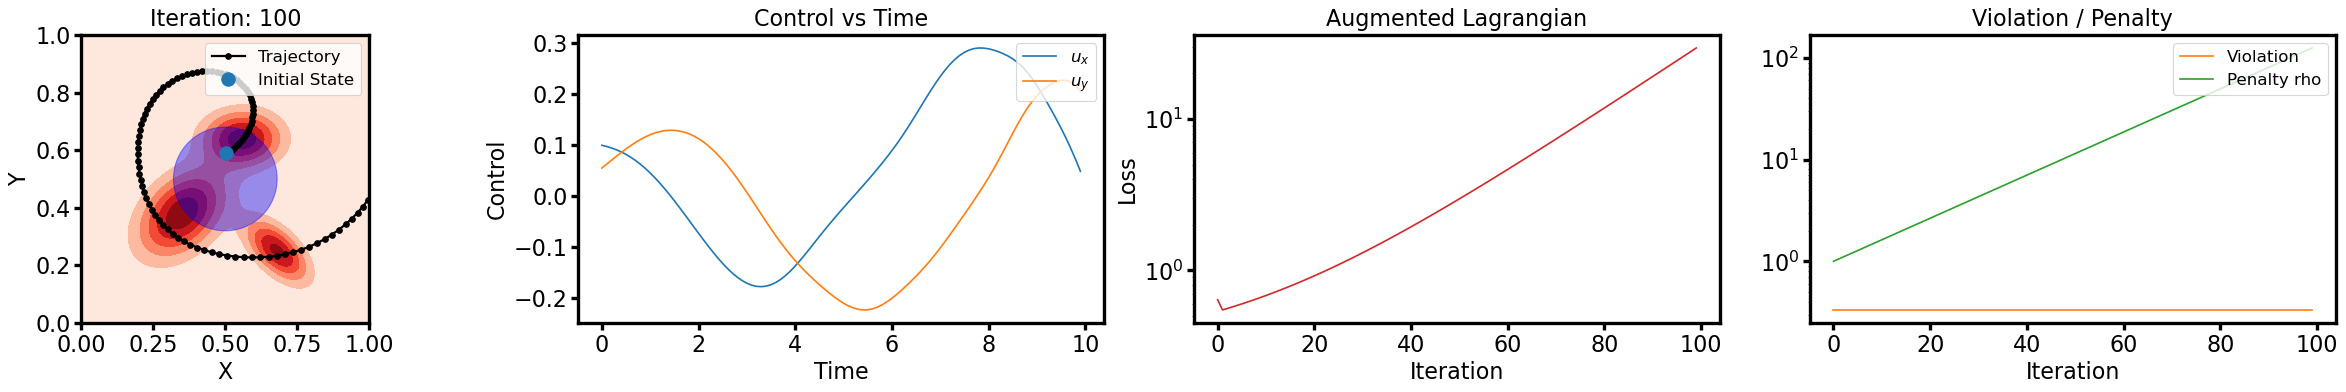

In [17]:
from IPython import display
from tqdm import tqdm

fig, axes = plt.subplots(
    1,
    4,
    dpi=80,
    figsize=(30,5),
    tight_layout=True,
)

for iter in tqdm(range(len(traj_list))):

    x_traj = traj_list[iter]

    # ======================================
    # subplot 1
    # trajectory
    # ======================================

    ax1 = axes[0]
    ax1.plot([0,1,1,0,0],[0,0,1,1,0], linewidth=3)

    ax1.cla()

    ax1.set_aspect('equal', adjustable='box')

    ax1.set_xlim(0.0, L_list[0])
    ax1.set_ylim(0.0, L_list[1])

    ax1.set_title(f'Iteration: {iter+1}')

    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')

    # target distribution
    ax1.contourf(
        grids_x,
        grids_y,
        pdf_vals.reshape(grids_x.shape),
        cmap='Reds'
    )

    # obstacle
    circle = plt.Circle(
        obstacle_center,
        obstacle_radius,
        color='blue',
        alpha=0.4
    )

    ax1.add_patch(circle)

    # trajectory
    ax1.plot(
        [x0[0], x_traj[0,0]],
        [x0[1], x_traj[0,1]],
        linestyle='--',
        linewidth=2,
        color='k',
    )

    ax1.plot(
        x_traj[:,0],
        x_traj[:,1],
        linestyle='-',
        marker='o',
        linewidth=2,
        color='k',
        label='Trajectory'
    )

    ax1.plot(
        x0[0],
        x0[1],
        marker='o',
        markersize=12,
        color='C0',
        linestyle='',
        label='Initial State'
    )

    ax1.legend(loc=1)

    # ======================================
    # subplot 2
    # control
    # ======================================

    ax2 = axes[1]

    ax2.cla()

    ax2.set_title('Control vs Time')

    ax2.plot(
        np.arange(tsteps) * dt,
        u_opt[:,0],
        color='C0',
        label=r'$u_x$'
    )

    ax2.plot(
        np.arange(tsteps) * dt,
        u_opt[:,1],
        color='C1',
        label=r'$u_y$'
    )

    ax2.set_xlabel('Time')

    ax2.set_ylabel('Control')

    ax2.legend(loc=1)

    # ======================================
    # subplot 3
    # objective
    # ======================================

    ax3 = axes[2]

    ax3.cla()

    ax3.set_title('Augmented Lagrangian')

    ax3.plot(
        np.arange(iter+1),
        loss_list[:iter+1],
        color='C3',
    )

    ax3.set_xlabel('Iteration')

    ax3.set_ylabel('Loss')

    ax3.set_yscale('log')

    # ======================================
    # subplot 4
    # constraint violation + rho
    # ======================================

    ax4 = axes[3]

    ax4.cla()

    ax4.set_title('Violation / Penalty')

    ax4.plot(
        np.arange(iter+1),
        violation_list[:iter+1],
        color='C1',
        label='Violation'
    )

    ax4.plot(
        np.arange(iter+1),
        rho_list[:iter+1],
        color='C2',
        label='Penalty rho'
    )

    ax4.set_xlabel('Iteration')

    ax4.set_yscale('log')

    ax4.legend(loc=1)

    # ======================================
    # dynamic display
    # ======================================

    display.clear_output(wait=True)

    display.display(fig)

display.clear_output(wait=True)

plt.show()

plt.close()